# Phase 7: Evaluation & Analysis

In this phase, we evaluate our fine-tuned `ResNet34` model on the completely unseen **test set**. This is our final measure of how well the model generalizes to new carabiner images.

We will compute:
- Accuracy
- Precision, Recall, and F1 Score (per class)
- The Confusion Matrix (focusing on false negatives, i.e., incorrectly classifying an open carabiner as closed)
- Grad-CAM visualizations to understand what structural parts the model focuses on when making its predictions.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import cv2

# Setup
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

PROCESSED_DATA_DIR = Path('../data/processed')
TEST_DIR = PROCESSED_DATA_DIR / 'test'
MODELS_DIR = Path('../models')
CHECKPOINT_PATH = MODELS_DIR / 'best_finetuned_resnet34.pth'

mean = [0.485, 0.456, 0.406] 
std = [0.229, 0.224, 0.225]

# We strictly use validation transforms for the test set (no data augmentation!)
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)
class_names = test_dataset.classes

print(f"Classes: {class_names}")
print(f"Test Dataset Size: {len(test_dataset)}")

Executing on device: cpu
Classes: ['closed', 'open']
Test Dataset Size: 128


### 1. Load the Fine-Tuned Model

In [2]:
from torchvision.models import ResNet34_Weights

model = models.resnet34(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

print(f"Loading fine-tuned weights from: {CHECKPOINT_PATH}")
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model = model.to(device)
model.eval()  # Set model to evaluate mode
print("Model loaded and set to evaluation mode.")

Loading fine-tuned weights from: ..\models\best_finetuned_resnet34.pth
Model loaded and set to evaluation mode.


### 2. Predict on Test Set & Calculate Metrics

In [3]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Classification Report:")
print("-" * 50)
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

      closed       0.95      0.98      0.96       107
        open       0.88      0.71      0.79        21

    accuracy                           0.94       128
   macro avg       0.91      0.85      0.88       128
weighted avg       0.94      0.94      0.93       128



### 3. Confusion Matrix Analyzer

We need to carefully observe the false negatives. Classifying an **Open** carabiner as **Closed** is a critical failure mode from a safety perspective.

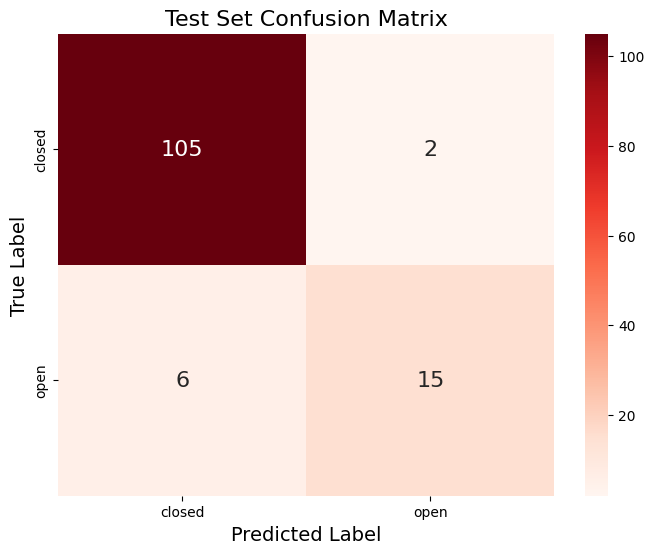

In [4]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names, 
            annot_kws={"size": 16})
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Test Set Confusion Matrix', fontsize=16)
plt.show()

### 4. Visualize Misclassified Images
Let's look at what the model got wrong, to see if there are any recognizable patterns.

Found 8 misclassified images. Displaying examples...


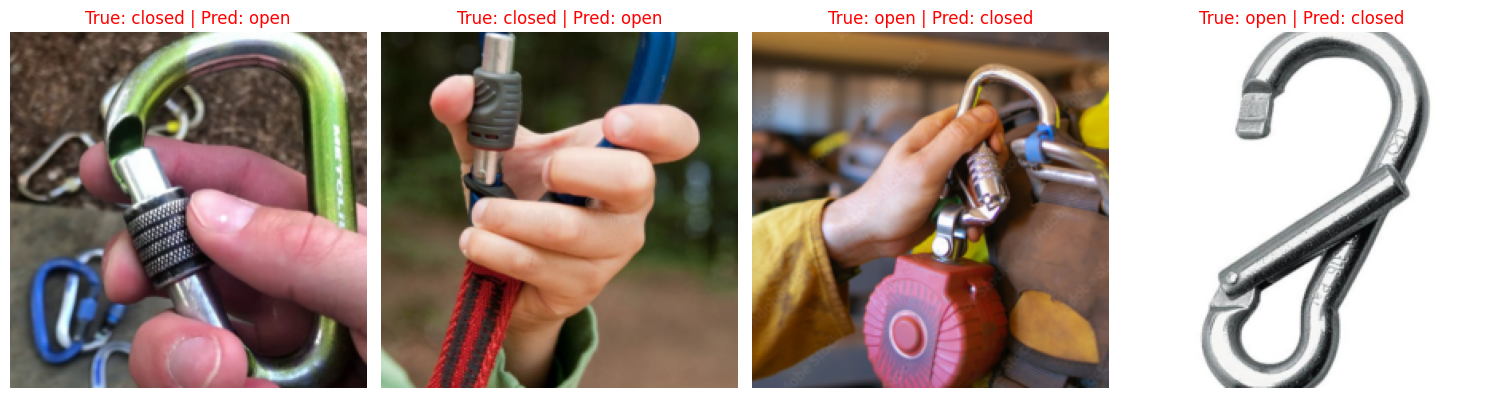

In [5]:
# Inverse transform for display purposes
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)

misclassified_idx = np.where(all_preds != all_labels)[0]

if len(misclassified_idx) == 0:
    print("Wow! 100% accuracy on the test set. No misclassified images found.")
else:
    print(f"Found {len(misclassified_idx)} misclassified images. Displaying examples...")
    
    num_to_show = min(4, len(misclassified_idx))
    fig, axes = plt.subplots(1, num_to_show, figsize=(15, 5))
    
    if num_to_show == 1:
        axes = [axes]
        
    for i, idx in enumerate(misclassified_idx[:num_to_show]):
        img_tensor = test_dataset[idx][0]
        true_label = class_names[all_labels[idx]]
        pred_label = class_names[all_preds[idx]]
        
        # Denormalize
        img = inv_normalize(img_tensor).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label} | Pred: {pred_label}", color='red')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

### 5. Heatmap Analysis (Grad-CAM)

We will run Grad-CAM to overlay attention heatmaps. The heatmaps will tell us what regional features strongly contributed to the model's prediction.

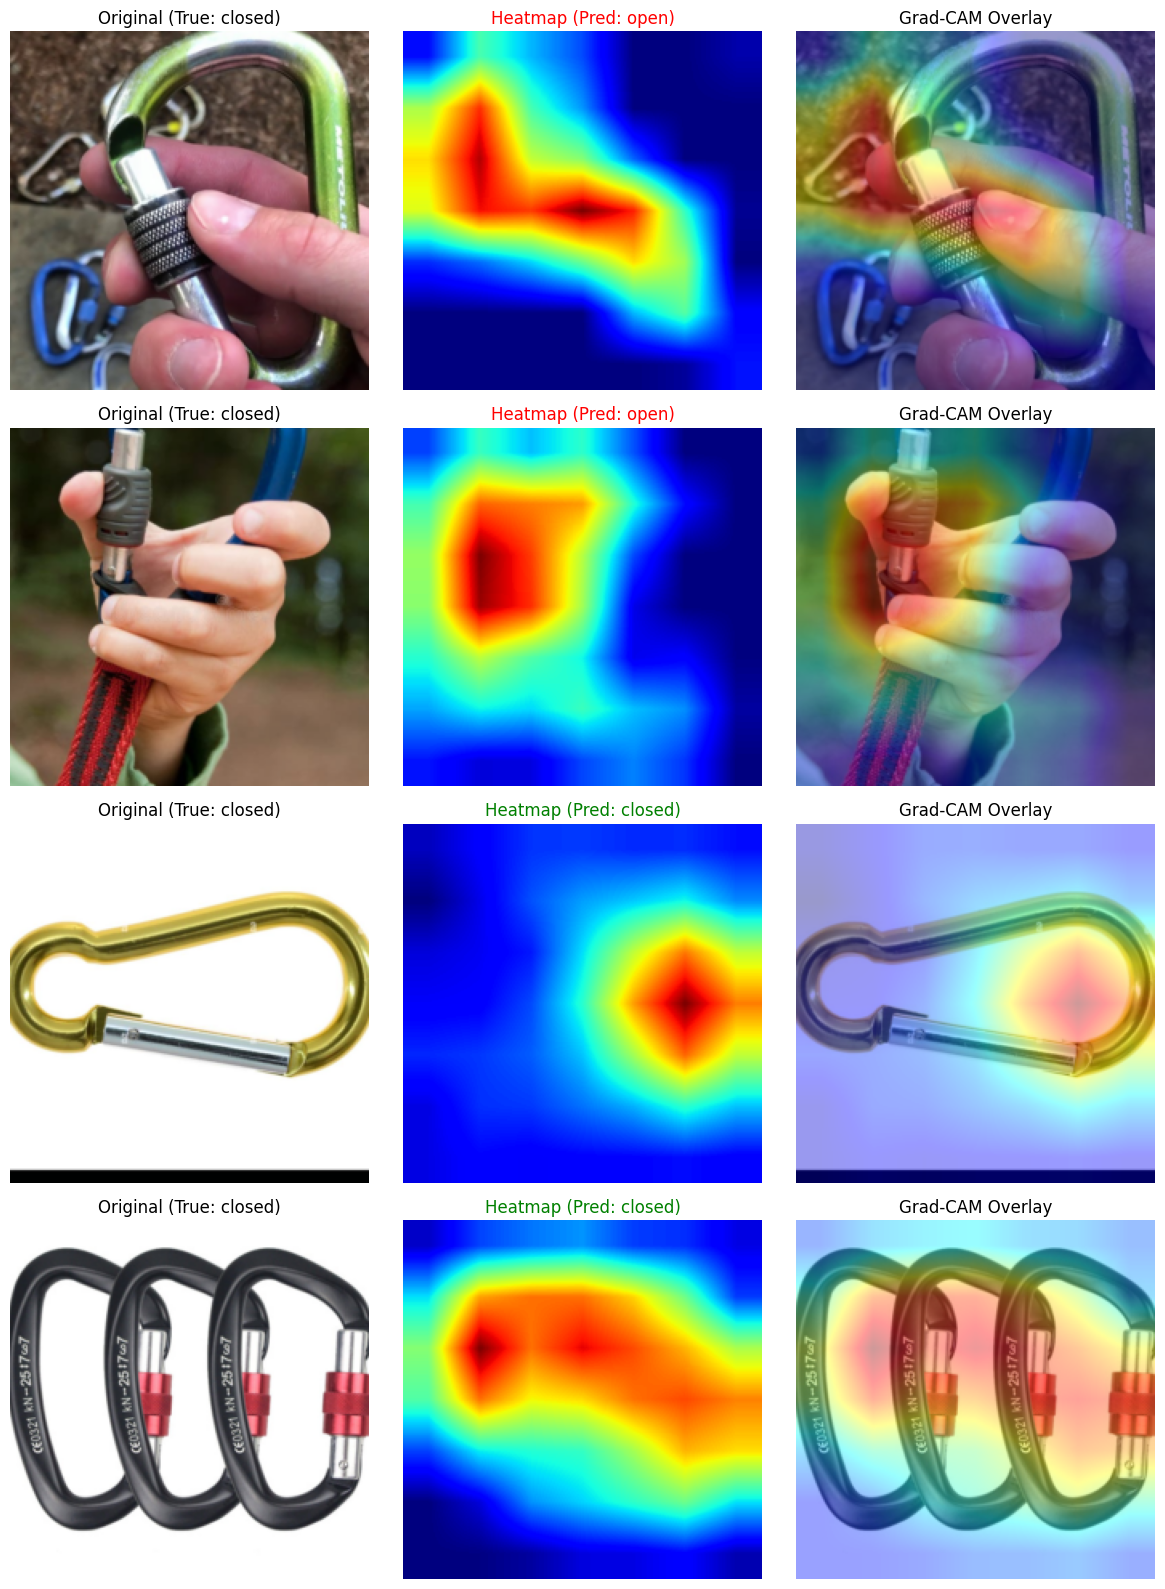

In [6]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook the target layer
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.model.eval()
        
        output = self.model(x)
        pred_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        output[0, pred_class].backward()
        
        # Global average pooling on gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight the channels by corresponding gradients
        activations = self.activations.detach()
        for i in range(activations.size(1)):
            activations[:, i, :, :] *= pooled_gradients[i]
            
        # Average and ReLU across the channels
        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        
        # Normalize 
        if torch.max(heatmap) != 0:
            heatmap /= torch.max(heatmap)
            
        return heatmap.cpu().detach().numpy(), pred_class


# We attach Grad-CAM to the final convolutional block of ResNet34
grad_cam = GradCAM(model, model.layer4[-1])

# Merge misclassified and a few correctly classified samples down for analysis 
correct_idx = np.where(all_preds == all_labels)[0]
idxs_to_show = list(misclassified_idx[:2]) + list(correct_idx[:2])

if len(idxs_to_show) == 0:
    idxs_to_show = [0, 1, 2, 3][:len(test_dataset)]

fig, axes = plt.subplots(len(idxs_to_show), 3, figsize=(12, 4 * len(idxs_to_show)))

if len(idxs_to_show) == 1:
    axes = [axes]

for row, idx in enumerate(idxs_to_show):
    img_tensor = test_dataset[idx][0].unsqueeze(0).to(device)
    
    heatmap, pred_c = grad_cam(img_tensor)
    
    img_disp = inv_normalize(test_dataset[idx][0]).permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp, 0, 1)
    
    # Resize heatmap to image size and create color overlay
    heatmap_resized = cv2.resize(heatmap, (img_disp.shape[1], img_disp.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = np.float32(heatmap_color) / 255
    heatmap_color = heatmap_color[..., ::-1] # BGR to RGB
    
    cam_img = heatmap_color * 0.4 + img_disp * 0.6
    cam_img = np.clip(cam_img, 0, 1)
    
    true_lbl = class_names[test_dataset[idx][1]]
    pred_lbl = class_names[pred_c]
    text_color = 'green' if true_lbl == pred_lbl else 'red'
    
    axes[row][0].imshow(img_disp)
    axes[row][0].set_title(f"Original (True: {true_lbl})")
    axes[row][0].axis('off')
    
    axes[row][1].imshow(heatmap_resized, cmap='jet')
    axes[row][1].set_title(f"Heatmap (Pred: {pred_lbl})", color=text_color)
    axes[row][1].axis('off')
    
    axes[row][2].imshow(cam_img)
    axes[row][2].set_title("Grad-CAM Overlay")
    axes[row][2].axis('off')

plt.tight_layout()
plt.show()